
# Condizionamento della valutazione di una funzione in un punto

## Esercizio 1 da esame - funzione razionale


Si consideri la funzione

$$
f(x)=\frac{1}{x-1},
$$

definita per $x\neq 1$.

Il problema consiste nel valutare $f(x)$ in punti vicini a $1$.

Si considerino i valori

$$
x_k = 1+10^{-k}, \qquad k=1,2,\dots,15.
$$

### Richieste

1. Implementare la funzione $f(x)=1/(x-1)$ e calcolare $f(x_k)$ per $k=1,\dots,15$. **[1 punti]**

2. Ricavare il numero di condizionamento relativo del problema di valutare $f$ in un punto $x$ **[4 punti]**

3. Calcolare $K_f(x_k)$ per i valori assegnati di $k$. **[1 punti]**

4. Perturbare i dati ponendo

$$
\widetilde{x}_k=x_k(1+\delta),
$$

con $\delta=10^{-12}$, e confrontare l'errore relativo sul dato con l'errore relativo sul risultato. **[2 punti]**

5. Rappresentare in un grafico, in scala logaritmica, il numero di condizionamento e il rapporto tra errore relativo sul risultato ed errore relativo sul dato. **[1 punti]**

6. Commentare i risultati ottenuti e spiegare perché il problema diventa mal condizionato quando $x$ si avvicina a $1$. **[1 punto]**

Totale: **10 punti**.


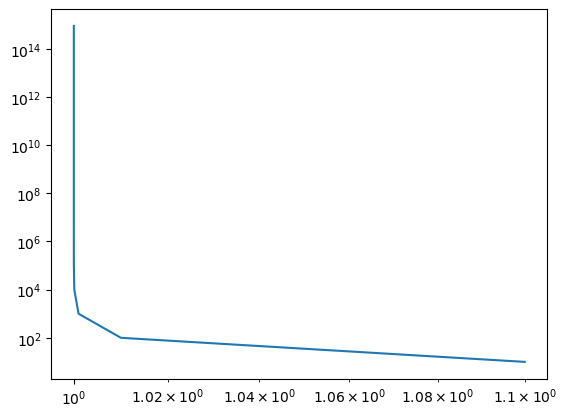

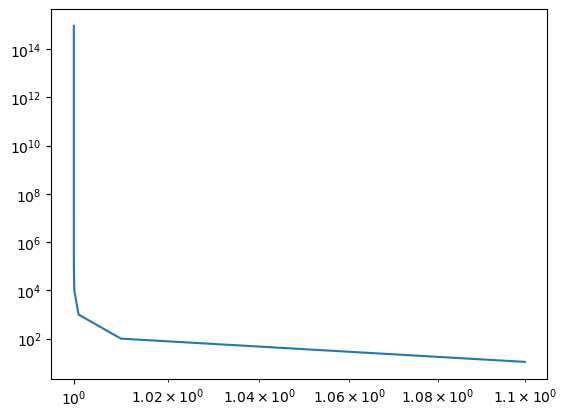

rapporto:  [1.10000000e+01 1.00999964e+02 1.00100004e+03 1.00009999e+04
 1.00000990e+05 1.00000000e+06 9.99990099e+06 9.99900017e+07
 9.99000829e+08 9.90098057e+09 9.09083494e+10 4.99955554e+11
 9.09083494e+11 9.90019703e+11 9.98802313e+11]


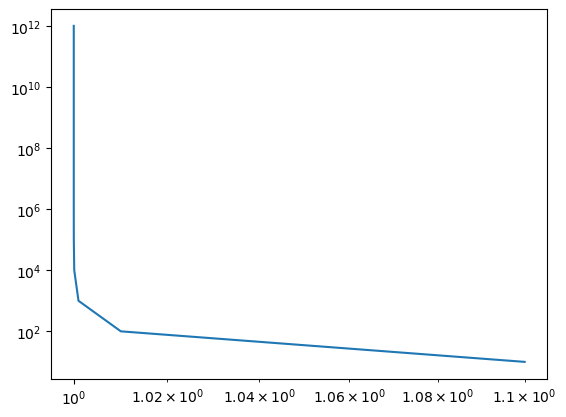

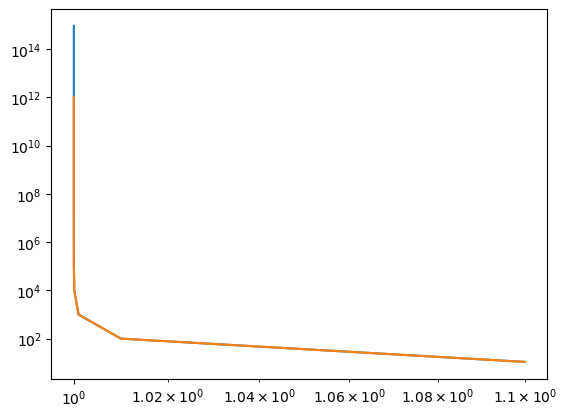

In [24]:
import numpy as np
import scipy.linalg as spl
import sympy as sym
import matplotlib.pyplot as plt

x = sym.symbols("x")
fx = 1 / (x-1)
fxl = sym.lambdify(x, fx, np)
k = np.arange(1, 16)
xk = 1 + 10.0**(-k)
plt.loglog(xk, fxl(xk))
df = sym.diff(fx, x, 1)
dfl = sym.lambdify(x, df, np)
# La formula di K è il modulo della frazione con a numeratore la derivata di f per x e denominatore la f
kf = sym.Abs((df * x) / (fx))
kfl = sym.lambdify(x, kf, np)
plt.show()
plt.loglog(xk, kfl(xk))

delta = 10.0 **(-12)
xkp = xk * (1 + delta)
plt.show()
plt.loglog(xkp, fxl(xkp))
err_dato = np.abs(xkp -xk ) / np.abs(xk)
err_ris = np.abs(fxl(xkp) - fxl(xk)) / np.abs(fxl(xk)) 
rapp = err_ris/err_dato
print("rapporto: ", rapp)
plt.show()
plt.loglog(xk, kfl(xk))
plt.loglog(xk, rapp)


Il grafico dimostra che quando $x$ si avvicina a $1$, il problema diventa fortemente mal condizionato perché la curva degli errori reali segue perfettamente l'impennata del condizionamento teorico fino a $10^{14}$. Questo accade perché al denominatore di $f(x) = \frac{1}{x-1}$ si verifica una cancellazione numerica: la differenza tra $x$ e $1$ diventa così microscopica che i bit di precisione del computer non bastano più, amplificando a dismisura anche la più piccola perturbazione iniziale sul dato e distruggendo l'accuratezza del risultato.